# Final Model Analysis & Evaluation

This notebook presents the final evaluation, comparison, feature importance analysis, and model saving for the Traffic Prediction project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Load Regression Data

In [2]:
X_train_reg = joblib.load('../Data/X_train_reg.pkl')
X_test_reg = joblib.load('../Data/X_test_reg.pkl')

y_train_reg = joblib.load('../Data/y_train_reg.pkl')
y_test_reg = joblib.load('../Data/y_test_reg.pkl')

# Load Classification Data

In [3]:
X_train_cls = joblib.load('../Data/X_train_cls.pkl')
X_test_cls = joblib.load('../Data/X_test_cls.pkl')

y_train_cls = joblib.load('../Data/y_train_cls.pkl')
y_test_cls = joblib.load('../Data/y_test_cls.pkl')

# Check Data

In [4]:
print("Regression Data")
print("X_train:", X_train_reg.shape)
print("X_test:", X_test_reg.shape)
print("y_train:", y_train_reg.shape)
print("y_test:", y_test_reg.shape)

print("\nClassification Data")
print("X_train:", X_train_cls.shape)
print("X_test:", X_test_cls.shape)
print("y_train:", y_train_cls.shape)
print("y_test:", y_test_cls.shape)

Regression Data
X_train: (38257, 66)
X_test: (7537, 66)
y_train: (38257,)
y_test: (7537,)

Classification Data
X_train: (38257, 66)
X_test: (7537, 66)
y_train: (38257,)
y_test: (7537,)


# Encode Classification Target

In [5]:
label_encoder = LabelEncoder()

y_train_cls_encoded = label_encoder.fit_transform(y_train_cls)
y_test_cls_encoded = label_encoder.transform(y_test_cls)

print("Classes:", label_encoder.classes_)

Classes: ['High' 'Low' 'Medium']


# Load Final Regression Model

In [6]:
final_reg_model = joblib.load(
    '../Models/best_xgb_reg.pkl'
)

# Load Final Classification Model

In [7]:
final_cls_model = joblib.load(
    '../Models/best_xgb_cls.pkl'
)

# Regression Predictions

In [8]:
reg_predictions = final_reg_model.predict(
    X_test_reg
)

# Regression Evaluation

In [9]:
reg_mae = mean_absolute_error(
    y_test_reg,
    reg_predictions
)

reg_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        reg_predictions
    )
)

reg_r2 = r2_score(
    y_test_reg,
    reg_predictions
)

print("Final Regression Results")
print("-" * 40)
print("MAE:", reg_mae)
print("RMSE:", reg_rmse)
print("R²:", reg_r2)

Final Regression Results
----------------------------------------
MAE: 278.0649057069191
RMSE: 486.6102633834828
R²: 0.9392289163642618


# Classification Predictions

In [10]:
cls_predictions_encoded = final_cls_model.predict(
    X_test_cls
)

# Classification Evaluation

In [11]:
cls_accuracy = accuracy_score(
    y_test_cls_encoded,
    cls_predictions_encoded
)

cls_precision = precision_score(
    y_test_cls_encoded,
    cls_predictions_encoded,
    average='weighted',
    zero_division=0
)

cls_recall = recall_score(
    y_test_cls_encoded,
    cls_predictions_encoded,
    average='weighted',
    zero_division=0
)

cls_f1 = f1_score(
    y_test_cls_encoded,
    cls_predictions_encoded,
    average='weighted',
    zero_division=0
)

print("Final Classification Results")
print("-" * 40)
print("Accuracy:", cls_accuracy)
print("Precision:", cls_precision)
print("Recall:", cls_recall)
print("F1 Score:", cls_f1)

Final Classification Results
----------------------------------------
Accuracy: 0.8967759055327054
Precision: 0.8987822238749218
Recall: 0.8967759055327054
F1 Score: 0.896712267097473


# Classification Report

In [12]:
print(
    classification_report(
        y_test_cls_encoded,
        cls_predictions_encoded,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.87      0.95      0.91      2508
         Low       0.97      0.91      0.94      2512
      Medium       0.87      0.83      0.85      2517

    accuracy                           0.90      7537
   macro avg       0.90      0.90      0.90      7537
weighted avg       0.90      0.90      0.90      7537



# Confusion Matrix

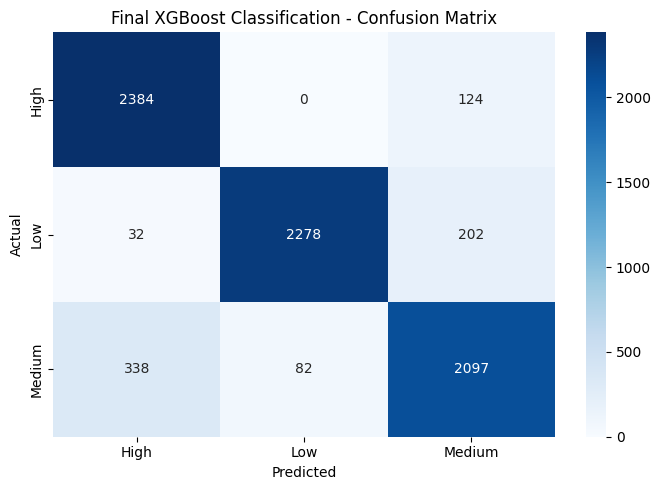

In [13]:
cm = confusion_matrix(
    y_test_cls_encoded,
    cls_predictions_encoded
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final XGBoost Classification - Confusion Matrix")

plt.tight_layout()
plt.show()

# Final Models Comparison

In [14]:
final_results = pd.DataFrame({
    'Task': [
        'Traffic Volume Prediction',
        'Congestion Level Classification'
    ],
    
    'Best Model': [
        'Tuned XGBoost Regressor',
        'Tuned XGBoost Classifier'
    ],
    
    'Main Metric': [
        'R²',
        'F1 Score'
    ],
    
    'Score': [
        reg_r2,
        cls_f1
    ]
})

final_results

,Task,Best Model,Main Metric,Score
0,Traffic Volume Prediction,Tuned XGBoost Regressor,R²,0.939229
1,Congestion Level Classification,Tuned XGBoost Classifier,F1 Score,0.896712


# Create Decision Support Function

In [15]:
def traffic_decision_support(
    traffic_volume,
    congestion_level
):
    
    if congestion_level == 'High':
        
        recommendation = (
            "High traffic congestion is expected. "
            "Consider avoiding peak hours or using an alternative route."
        )
    
    elif congestion_level == 'Medium':
        
        recommendation = (
            "Moderate traffic congestion is expected. "
            "Allow extra travel time."
        )
    
    else:
        
        recommendation = (
            "Low traffic congestion is expected. "
            "Traffic conditions are favorable."
        )
    
    return {
        'Predicted Traffic Volume': round(traffic_volume),
        'Congestion Level': congestion_level,
        'Recommendation': recommendation
    }

# Test Decision Support

In [16]:
sample_result = traffic_decision_support(
    traffic_volume=5500,
    congestion_level='High'
)

sample_result

{'Predicted Traffic Volume': 5500,
 'Congestion Level': 'High',
 'Recommendation': 'High traffic congestion is expected. Consider avoiding peak hours or using an alternative route.'}

# Combine Regression + Classification Predictions

In [17]:
predicted_congestion = label_encoder.inverse_transform(
    cls_predictions_encoded
)

decision_results = pd.DataFrame({
    'Actual Traffic Volume': y_test_reg.values,
    'Predicted Traffic Volume': reg_predictions,
    'Actual Congestion Level': y_test_cls.values,
    'Predicted Congestion Level': predicted_congestion
})

decision_results.head(10)

,Actual Traffic Volume,Predicted Traffic Volume,Actual Congestion Level,Predicted Congestion Level
0,1478.0,665.026550,Low,Low
1,1408.0,121.433609,Low,Low
2,931.0,57.517639,Low,Low
3,585.0,64.909103,Low,Low
4,381.0,538.907837,Low,Low
5,434.0,2131.197021,Low,Medium
6,677.0,4182.445312,Low,High
7,811.0,3871.808105,Low,Medium
8,1122.0,3318.287598,Low,Medium
9,1738.0,2866.160645,Low,Medium


# Add Recommendation

In [18]:
def get_recommendation(level):
    
    if level == 'High':
        return "Avoid peak hours or consider an alternative route."
    
    elif level == 'Medium':
        return "Expect moderate delays and allow extra travel time."
    
    else:
        return "Traffic conditions are favorable."

# Generate Recommendations

In [19]:
decision_results['Recommendation'] = (
    decision_results['Predicted Congestion Level']
    .apply(get_recommendation)
)

decision_results.head(10)

,Actual Traffic Volume,Predicted Traffic Volume,Actual Congestion Level,Predicted Congestion Level,Recommendation
0,1478.0,665.026550,Low,Low,Traffic conditions are favorable.
1,1408.0,121.433609,Low,Low,Traffic conditions are favorable.
2,931.0,57.517639,Low,Low,Traffic conditions are favorable.
3,585.0,64.909103,Low,Low,Traffic conditions are favorable.
4,381.0,538.907837,Low,Low,Traffic conditions are favorable.
5,434.0,2131.197021,Low,Medium,Expect moderate delays and allow extra travel ...
6,677.0,4182.445312,Low,High,Avoid peak hours or consider an alternative ro...
7,811.0,3871.808105,Low,Medium,Expect moderate delays and allow extra travel ...
8,1122.0,3318.287598,Low,Medium,Expect moderate delays and allow extra travel ...
9,1738.0,2866.160645,Low,Medium,Expect moderate delays and allow extra travel ...


# Final Decision Support Output

In [20]:
decision_results[
    [
        'Predicted Traffic Volume',
        'Predicted Congestion Level',
        'Recommendation'
    ]
].head(20)

,Predicted Traffic Volume,Predicted Congestion Level,Recommendation
0,665.026550,Low,Traffic conditions are favorable.
1,121.433609,Low,Traffic conditions are favorable.
2,57.517639,Low,Traffic conditions are favorable.
3,64.909103,Low,Traffic conditions are favorable.
4,538.907837,Low,Traffic conditions are favorable.
5,2131.197021,Medium,Expect moderate delays and allow extra travel ...
6,4182.445312,High,Avoid peak hours or consider an alternative ro...
7,3871.808105,Medium,Expect moderate delays and allow extra travel ...
8,3318.287598,Medium,Expect moderate delays and allow extra travel ...
9,2866.160645,Medium,Expect moderate delays and allow extra travel ...


# Save Final Results

In [21]:
decision_results.to_csv(
    '../Data/final_decision_results.csv',
    index=False
)

# Save Final Models

In [22]:
joblib.dump(
    final_reg_model,
    '../Data/final_regression_model.pkl'
)

joblib.dump(
    final_cls_model,
    '../Data/final_classification_model.pkl'
)

joblib.dump(
    label_encoder,
    '../Data/classification_label_encoder.pkl'
)

['../Data/classification_label_encoder.pkl']